# Can shared vocabulary fix consensus blind spots? (T8 evaluation demo)

**Setting.** No gold formula is available, so an NL→FOL candidate is judged by **cross-family consensus**. A candidate is
*endorsed* when more than half of its family-disjoint peers (formalizations of the same sentence by *other* model
families) agree with it. The eval-2 metric `END_MAJ` counts a peer as agreeing when the two formulas are
exactly equal or equivalent after predicate alignment. Two error rates describe it:

* **e** = P(endorsed | ERROR): wrong formalizations that the consensus endorses anyway (a blind spot),
* **d** = P(not endorsed | CORRECT): correct formalizations that the consensus rejects.

Under `END_MAJ`, `d = 0.537`: more than half of the correct candidates are rejected. This evaluation (T8, CPU only,
no LLM calls, $0) asks **how much of `d` a shared vocabulary could remove**. Each (candidate, peer) pair gets a class:
`EXACT`, `NAME_ONLY` (equal after symbol normalisation), `ALIGN_ONLY`, `VOCAB` (equivalent only under exp-8's
NF/hybrid vocabulary matching) or `IRREDUCIBLE`. Then `e`/`d` are recomputed under counting rules that treat more
classes as agreement.

**Headline (full run, 2,672 rows).** Most of `d` is *irreducible*: 69% of pairs match no vocabulary rule. The predicted
floor for `d` under a shared vocabulary is 0.402 (3-family pool), against 0.415 today.

**This notebook** walks through the original `eval.py` orchestrator. It then re-runs the core Part-1 computation
(counting rules → endorsement → e/d decomposition with sentence-cluster bootstrap CIs, plus the label-free `c_vres`
score) on a **100-row curated subset** (`mini_demo_data.json`) and compares the results with the full-run numbers.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, scipy, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'matplotlib==3.10.0')

In [2]:
# --- original eval.py import block ---
from __future__ import annotations

import argparse
import os
import subprocess
import sys
import time
from pathlib import Path

from loguru import logger

# --- additional imports used by the Part-1 / eval_out code reproduced below (src/t8_part1.py, src/t8_eval_out.py,
#     eval-2 stats.py / mechanism.py) and for the final visualization ---
import json
import numpy as np
import pandas as pd
from scipy.stats import rankdata
import matplotlib.pyplot as plt

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/fork/run_An1uy2kF2SjZ/round-4/evaluation-3/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["metadata"]["demo_subset"])
print("examples:", len(data["examples"]), "| full-run metrics:", len(data["metrics_agg_full_run"]))

100 rows of E_R_AB_consensus_scorable: 50 ERROR + 50 CORRECT, each label stratified proportionally by stratum (CTRL/L20/EXC/L25), random.Random(0); full dataset has 2,672 rows (1,810 ERROR / 862 CORRECT)
examples: 100 | full-run metrics: 157


## Configuration

Every tunable parameter is set here. The original values are in the comments. The demo runs at the original `B` and
`N_MC`, because on 100 rows both take a few seconds.

In [5]:
N_ROWS = 100      # rows of mini_demo_data.json to use (max 100 here; the full E dataset has 2,672)
B = 2000          # sentence-cluster bootstrap replicates (original: B = 2000)
N_MC = 500        # Monte-Carlo draws for R_point_MC (original: N_MC = 500)
SEED = 0          # bootstrap / MC seed (original: 0)
POOLS = ("3pool", "9fam")   # 3pool = matched deepseek/microsoft/openai peer pool (PRIMARY); 9fam = all families
RUN_PIPELINE = False        # True would run the original eval.py main(), which needs src/ and the upstream workspaces

## 1. The original orchestrator: `eval.py`

`eval.py` does no computation itself. It runs the plan's steps in order as subprocesses. The pre-registration is
written and hashed **before** any Part-1 number exists. The R_COMP pair matrix is built in stages (mini → s50 → all).
Then come Part 1 (vocabulary pair classes and counting rules), Part 3 (power analysis for iteration 5), Part 2 (R_COMP
second population), Part 4 (verified record tables), figures, an independent re-derivation audit, and finally
`eval_out.json`.

The code is unchanged except for one line: `ROOT` becomes the notebook's working directory, because a notebook has no
`__file__`. `main()` is only called when `RUN_PIPELINE = True`, because the step scripts read read-only upstream
workspaces (eval-2's pair matrices, exp-8's `pairs_E.jsonl`) that are not shipped with this demo.

In [6]:
ROOT = Path.cwd()   # original: Path(__file__).resolve().parent
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
logger.add(ROOT / "logs" / "eval.log", rotation="30 MB", level="DEBUG")

STEPS = [("prereg", ["src/t8_prereg.py"]),
         ("matrix_mini", ["src/t8_run_rcomp_matrix.py", "--stage", "mini"]),
         ("matrix_s50", ["src/t8_run_rcomp_matrix.py", "--stage", "s50"]),
         ("matrix_all", ["src/t8_run_rcomp_matrix.py", "--stage", "all"]),
         ("part1", ["src/t8_part1.py"]), ("part1_net", ["src/t8_part1_net.py"]), ("part3", ["src/t8_part3.py"]),
         ("part2", ["src/t8_part2.py"]), ("part4", ["src/t8_part4.py"]), ("figs", ["src/t8_figs.py"]),
         ("audit", ["audit/rederive.py"]), ("eval_out", ["src/t8_eval_out.py"]), ("record_md", ["src/t8_record_md.py"])]


@logger.catch(reraise=True)
def main() -> None:
    ap = argparse.ArgumentParser()
    ap.add_argument("--skip-matrix", action="store_true", help="reuse results/pair_matrix_RCOMP.jsonl")
    ap.add_argument("--from", dest="start", default="prereg", choices=[s for s, _ in STEPS])
    a = ap.parse_args([])   # notebook: no CLI args (original: ap.parse_args())
    env = dict(os.environ, PYTHONHASHSEED="0", PYTHONDONTWRITEBYTECODE="1")
    names = [s for s, _ in STEPS]
    for name, cmd in STEPS[names.index(a.start):]:
        if a.skip_matrix and name.startswith("matrix"):
            continue
        t0 = time.time()
        logger.info(f"step {name}: {' '.join(cmd)}")
        subprocess.run([sys.executable, *cmd], cwd=ROOT, env=env, check=True)
        logger.info(f"step {name} done in {time.time() - t0:.0f}s")


if RUN_PIPELINE:
    main()
else:
    for i, (name, cmd) in enumerate(STEPS, 1):
        logger.info(f"step {i:2d} {name:<11} -> {' '.join(cmd)}")

16:44:50|INFO   |step  1 prereg      -> src/t8_prereg.py


16:44:50|INFO   |step  2 matrix_mini -> src/t8_run_rcomp_matrix.py --stage mini


16:44:50|INFO   |step  3 matrix_s50  -> src/t8_run_rcomp_matrix.py --stage s50


16:44:50|INFO   |step  4 matrix_all  -> src/t8_run_rcomp_matrix.py --stage all


16:44:50|INFO   |step  5 part1       -> src/t8_part1.py


...

16:44:50|INFO   |step  9 part4       -> src/t8_part4.py


16:44:50|INFO   |step 10 figs        -> src/t8_figs.py


16:44:50|INFO   |step 11 audit       -> audit/rederive.py


16:44:50|INFO   |step 12 eval_out    -> src/t8_eval_out.py


16:44:50|INFO   |step 13 record_md   -> src/t8_record_md.py


## 2. Per-row data: the `eval_out.json` example records

`src/t8_eval_out.py` writes one example per consensus-scorable row of dataset E (the `R_AB` population). Each record
holds the sentence's complexity stratum, word count and number of conditions; the candidate's label (`ERROR` /
`CORRECT`); `npc` (the number of family-disjoint peers); **the number of peer pairs in each vocabulary class** for the
9-family and 3-family pools; and each counting rule's endorsement.

The cell below keeps the helper `f()` from `t8_eval_out.py` and reverses the example-building loop to turn the records
back into the row frame `P` that Part 1 works on. `y_AB = 1` means ERROR.

In [7]:
def f(x):
    return None if x is None or (isinstance(x, float) and np.isnan(x)) else float(x)


CLASSES = ("EXACT", "NAME_ONLY", "ALIGN_ONLY", "VOCAB", "IRREDUCIBLE")
STORED_RULES = ("R_exact", "R_align", "R_name", "R_point_label", "R_liberal", "R_oracle")

rows = []
for ex in data["examples"][:N_ROWS]:
    inp = json.loads(ex["input"])
    r = {"sentence_id": inp["sentence_id"], "row_key": inp["row_key"], "stratum": inp["stratum"], "words": inp["words"],
         "n_conditions": inp["n_conditions"], "family_vendor": inp["family"], "candidate_fol": inp["candidate_fol"],
         "y_AB": int(ex["eval_y_error"]), "npc": ex["metadata_npc"]}
    for c in CLASSES:
        r[c] = ex[f"metadata_n_pairs_{c}"]
        r[f"{c}_3pool"] = ex[f"metadata_n_pairs_{c}_3pool"]
    for pool in ("9fam", "3pool"):
        for rule in STORED_RULES:
            v = ex[f"predict_endorse_{rule}_{pool}"]
            r[f"stored_en_{pool}_{rule}"] = np.nan if v == "NA" else float(v)
        v = ex[f"predict_c_vres_{pool}"]
        r[f"stored_c_vres_{pool}"] = np.nan if v == "NA" else float(v)
    rows.append(r)
P = pd.DataFrame(rows)
print(P.shape, "| ERROR rows:", int(P.y_AB.sum()), "| CORRECT rows:", int((P.y_AB == 0).sum()),
      "| sentences:", P.sentence_id.nunique())
P[["sentence_id", "stratum", "words", "n_conditions", "family_vendor", "y_AB", "npc", *CLASSES]].head(8)

(100, 33) | ERROR rows: 50 | CORRECT rows: 50 | sentences: 82


,sentence_id,stratum,words,n_conditions,family_vendor,y_AB,npc,EXACT,NAME_ONLY,ALIGN_ONLY,VOCAB,IRREDUCIBLE
0,025e45bba5ad,CTRL,7,0,meta,0,10,8,0,0,0,2
1,203fddc52abf,EXC,18,5,deepseek,0,11,1,0,1,0,9
2,0a0c453be0f1,L25,28,5,microsoft,0,11,0,0,6,0,5
3,041807d4a821,L20,20,3,cohere,1,12,0,0,0,0,12
4,14d8aea91a51,EXC,23,1,mistral,1,10,0,0,0,0,10
5,7745ec1c39cf,L25,35,5,qwen,1,9,1,0,1,0,7
6,723929a1dbc7,EXC,15,1,mistral,1,11,0,0,0,0,11
7,00c40ad04640,L20,22,4,qwen,0,10,4,0,0,0,6


Here are a few candidates with their peer-pair class counts. Most pairs of a correct candidate fall in `IRREDUCIBLE`:
the peer is not equivalent even when vocabulary is ignored.

In [8]:
pd.set_option("display.max_colwidth", 90)
P[["stratum", "y_AB", "candidate_fol", "EXACT", "ALIGN_ONLY", "VOCAB", "IRREDUCIBLE"]].sample(6, random_state=SEED)

,stratum,y_AB,candidate_fol,EXACT,ALIGN_ONLY,VOCAB,IRREDUCIBLE
26,L20,0,"∀x (Food(x) ∧ DerivedFrom(x, plants) ∧ ¬Contain(x, animalProducts) ∧ RichIn(x, nutrien...",0,5,0,6
86,L25,1,"∀x ∀y ∀z (DevelopedFor(x, y, z) ↔ (WritesCodeFor(y, x) ∧ FundsProject(z, x) ∧ Employed...",0,1,0,7
2,L25,0,"∀x ((LivingOrganism(x) ∧ CanSynthesizeOwnFoodThrough(x, photosynthesis) ∧ AbsorbsNutri...",0,6,0,5
55,CTRL,0,"∀x (Disease(x) → (Affects(x, females) ∨ Affects(x, males)))",2,3,0,6
75,L25,0,∀x (Cell(x) → ((ReachesEndOfCellCycle(x) ∧ CompletedDNAReplication(x) ∧ ¬InCellularArr...,1,6,0,4
93,L20,1,"∀x (Building(x) ∧ Contains(x, books) ∧ Contains(x, manuscripts) ∧ Contains(x, otherMat...",0,0,0,10


## 3. Statistics helpers (imported unchanged from eval-2)

T8 imports eval-2's statistics **unchanged** (code sha `dd73975642f428cc`); they are copied here verbatim:

* `auc`: tie-aware Mann-Whitney AUROC; `strat_auc`: within-stratum pair AUROC (weights `n_err,s · n_cor,s`),
* `ci`: 2.5/97.5 percentile interval; `SentBoot`: a **sentence-cluster** bootstrap stored as a `(B, n_rows)`
  multiplicity-weight matrix, because rows of one sentence are not independent,
* `ed_decomposition`: `e`, `d` and the bookkeeping identity `AUROC_b = 1 − (e + d)/2` for the binary score
  `b = 1 − endorsed`,
* `make_bins`: the pre-registered complexity cuts (word terciles at 20 / 26 words, number-of-conditions bins).

In [9]:
MIN_ROWS, MIN_SENT = 30, 10   # eval-2 mechanism.py: a cell is 'testable' with >= 30 rows and >= 10 sentences


def auc(y, s) -> float:
    '''Mann-Whitney AUROC with ties = 0.5 (identical to sklearn roc_auc_score).'''
    y = np.asarray(y, dtype=float)
    s = np.asarray(s, dtype=float)
    n1 = int(y.sum())
    n0 = len(y) - n1
    if n1 == 0 or n0 == 0:
        return float("nan")
    r = rankdata(s)
    return float((r[y == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * n0))


def strat_auc(y, s, strata) -> float:
    '''Within-stratum pair AUROC: sum_s w_s AUROC_s with w_s = n_err,s * n_cor,s (exp 5 'stratified').'''
    y, s, strata = np.asarray(y, float), np.asarray(s, float), np.asarray(strata)
    num = den = 0.0
    for st in np.unique(strata):
        m = strata == st
        n1 = int(y[m].sum())
        n0 = int(m.sum()) - n1
        if n1 and n0:
            num += auc(y[m], s[m]) * n1 * n0
            den += n1 * n0
    return num / den if den else float("nan")


def ci(vals, lo=2.5, hi=97.5):
    v = np.asarray([x for x in vals if x is not None and not np.isnan(x)], float)
    if len(v) == 0:
        return [None, None]
    return [float(np.percentile(v, lo)), float(np.percentile(v, hi))]


class SentBoot:
    '''Sentence-cluster bootstrap as multiplicity weights: W[b, i] = #times row i's sentence was drawn in replicate b
    (numpy default_rng(seed); sentence_ids resampled with replacement).'''

    def __init__(self, sids, b: int = 2000, seed: int = 0):
        sids = np.asarray(sids)
        self.keys, self.sent_ix = np.unique(sids, return_inverse=True)
        S = len(self.keys)
        rng = np.random.default_rng(seed)
        self.C = np.stack([np.bincount(rng.integers(0, S, S), minlength=S) for _ in range(b)]).astype(float)
        self.B = b

    def weights(self, b: int, mask=None):
        w = self.C[b][self.sent_ix]
        return w if mask is None else w[mask]

    def W(self, mask=None):
        '''(B, n_rows[mask]) weight matrix.'''
        W = self.C[:, self.sent_ix]
        return W if mask is None else W[:, mask]


def ed_decomposition(y, endorsed) -> dict:
    '''y: 1 = ERROR, 0 = CORRECT; endorsed: 1 = the cross-family peer rule endorses the candidate.
    Returns e = P(endorsed | ERROR) (error-endorsement), d = P(not endorsed | CORRECT) (correct-divergence) and
    AUROC_b of b = 1 - endorsed, asserting the bookkeeping identity AUROC_b = 1 - (e + d)/2 (balanced accuracy).'''
    y = np.asarray(y, int)
    en = np.asarray(endorsed, int)
    e = float(en[y == 1].mean())
    d = float((1 - en[y == 0]).mean())
    a = auc(y, 1 - en)
    assert abs(a - (1 - (e + d) / 2)) < 1e-12, (a, e, d)
    return {"n_err": int((y == 1).sum()), "n_cor": int((y == 0).sum()), "e": e, "d": d, "auroc_b": a}


def make_bins(df: pd.DataFrame, cut: dict) -> pd.DataFrame:
    q1, q2 = cut["words_tercile_cuts"]
    df = df.copy()
    df["words_t"] = np.where(df.words <= q1, "T1", np.where(df.words <= q2, "T2", "T3"))
    nc = df.n_conditions.fillna(-1).astype(int)
    df["ncond_bin"] = np.where(nc <= 1, "0-1", np.where(nc == 2, "2", np.where(nc == 3, "3", "4+")))
    # (exc_bin omitted: exception_type is not part of the eval_out example records)
    df["long"] = df.stratum.isin(["L25", "L20", "EXC"])
    return df


P = make_bins(P, {"words_tercile_cuts": data["prereg"]["words_tercile_cuts"]})
print("word-tercile cuts:", data["prereg"]["words_tercile_cuts"])
print(P.groupby(["words_t", "y_AB"]).size().unstack(fill_value=0))

word-tercile cuts: [20.0, 26.0]
y_AB      0   1
words_t        
T1       26  15
T2       18  17
T3        6  18


## 4. Counting rules → endorsement (Part 1, `src/t8_part1.py`)

These are the pre-registered rules (`prereg_d_split.json`). A candidate is **endorsed iff #agreeing peers > n/2**, where `n`
is the number of family-disjoint peers in the pool:

| rule | a peer agrees when the pair is … |
|---|---|
| `R_exact` | `EXACT` |
| `R_align` (= `END_MAJ`) | `EXACT` or align-equivalent |
| `R_name` | `R_align` or `NAME_ONLY` |
| `R_liberal` | `R_name` plus every `VOCAB` pair (a lower bound on reachable `d`) |
| `R_point_MC` | `R_name` plus each `VOCAB` pair accepted with probability 0.612 (the exp-8 label-concordance rate), 500 MC draws |
| `R_point_label` | the PRIMARY, oracle-assisted prediction: `VOCAB` pairs count only when the peer's label is consistent |
| `R_oracle` | no-anchoring floor: endorsed iff > half of the peers are *labelled* CORRECT |

The original `endorse_det` / `endorse_mc` loop over the per-pair table `Q`. The demo has only per-row **class counts**,
so the cell below uses the counts in place of `np.bincount(ci_, weights=agree)`. Everything else is the original code:
the `k > n/2` threshold, NaN for rows with no peer in the pool, and the MC draw `U < p_acc` per VOCAB pair.
In this data every `NAME_ONLY` pair is also align-equivalent in the eval-2 matrix, so `R_align` counts
`EXACT + NAME_ONLY + ALIGN_ONLY` and equals `R_name`. With that, this cell reproduces the stored `R_align` endorsement on
100% of the 2,672 full-run rows.

`R_point_label` and `R_oracle` need each **peer's own label**, which the per-row records do not include. For those two
rules the notebook uses the per-row values from the full run (the MC mean for `R_point_label`).

In [10]:
RULES_DET = ["R_exact", "R_align", "R_name", "R_liberal"]
RULES_MC = ["R_point_MC"]
RULES_STORED = ["R_point_label", "R_oracle"]
RULES = RULES_DET + RULES_MC + RULES_STORED
p_acc = float(data["prereg"]["p_accept_vocab"])   # 1 - vocab discount 0.3876 = 0.612


def endorse_det(P: pd.DataFrame, pool: str) -> dict:
    '''Deterministic endorsement per rule for every P row (NaN when the pool has no rows) -- from per-row class counts.'''
    sfx = "" if pool == "9fam" else "_3pool"
    C = {c: P[f"{c}{sfx}"].values.astype(float) for c in CLASSES}
    n = sum(C.values())                                # family-disjoint peers of this candidate in the pool
    agree = {
        "R_exact": C["EXACT"], "R_align": C["EXACT"] + C["NAME_ONLY"] + C["ALIGN_ONLY"],
        "R_name": C["EXACT"] + C["NAME_ONLY"] + C["ALIGN_ONLY"],
        "R_liberal": C["EXACT"] + C["NAME_ONLY"] + C["ALIGN_ONLY"] + C["VOCAB"]}
    out = {}
    with np.errstate(invalid="ignore", divide="ignore"):
        for r, k in agree.items():
            out[r] = np.where(n > 0, (k > n / 2).astype(float), np.nan)
        out["_n"] = n
        out["_agree_liberal"] = agree["R_liberal"]
        out["_agree_align"] = agree["R_align"]
    return out


def endorse_mc(P: pd.DataFrame, pool: str, p_acc: float, seed: int = 0) -> dict:
    '''(N_MC, n_rows) endorsement draws for R_point_MC: R_name plus each VOCAB pair accepted with prob p_acc.'''
    sfx = "" if pool == "9fam" else "_3pool"
    n = sum(P[f"{c}{sfx}"].values.astype(float) for c in CLASSES)
    base = (P[f"EXACT{sfx}"] + P[f"NAME_ONLY{sfx}"] + P[f"ALIGN_ONLY{sfx}"]).values.astype(float)
    ci_ = np.repeat(np.arange(len(P)), P[f"VOCAB{sfx}"].values.astype(int))   # one entry per VOCAB pair -> its row
    rng = np.random.default_rng(seed)
    U = rng.random((N_MC, len(ci_)))
    out = {}
    for name, prob in (("R_point_MC", np.full(len(ci_), p_acc)),):
        acc = (U < prob[None, :]).astype(float)
        K = np.zeros((N_MC, len(P)))
        np.add.at(K.T, ci_, acc.T)
        with np.errstate(invalid="ignore"):
            out[name] = np.where(n[None, :] > 0, ((base[None, :] + K) > n[None, :] / 2).astype(float), np.nan)
    return out


ENs, Ds = {}, {}
for pool in POOLS:
    D = endorse_det(P, pool)
    EN = {r: D[r] for r in RULES_DET}
    EN.update(endorse_mc(P, pool, p_acc, seed=SEED))
    for r in RULES_STORED:
        EN[r] = P[f"stored_en_{pool}_{r}"].values
    ENs[pool], Ds[pool] = EN, D
    print(f"[{pool}] rows with >=1 peer in pool: {int((D['_n'] > 0).sum())}/{len(P)} "
          f"(excluded, no pool peers: {int((D['_n'] == 0).sum())})")

[3pool] rows with >=1 peer in pool: 99/100 (excluded, no pool peers: 1)


[9fam] rows with >=1 peer in pool: 100/100 (excluded, no pool peers: 0)


**Check against the full run.** The recomputed deterministic endorsements should equal the per-row values stored in
`eval_out.json` exactly. `R_point_MC` is random, so its draw mean should be close to the stored `R_point_label` value
on rows whose VOCAB peers are unlabelled.

In [11]:
chk = []
for pool in POOLS:
    for r in RULES_DET:
        a, s = ENs[pool][r], P[f"stored_en_{pool}_{r}"].values
        ok = ~np.isnan(s)
        chk.append({"pool": pool, "rule": r, "n_rows": int(ok.sum()), "match_rate": float((a[ok] == s[ok]).mean()),
                    "NaN pattern equal": bool(np.array_equal(np.isnan(a), np.isnan(s)))})
    s = P[f"stored_c_vres_{pool}"].values
    n = Ds[pool]["_n"]
    c_v = np.where(n > 0, 1 - Ds[pool]["_agree_liberal"] / np.where(n > 0, n, 1), np.nan)
    ok = ~np.isnan(s)
    chk.append({"pool": pool, "rule": "c_vres (score)", "n_rows": int(ok.sum()),
                "match_rate": float((np.abs(c_v[ok] - s[ok]) < 5e-5).mean()),
                "NaN pattern equal": bool(np.array_equal(np.isnan(c_v), np.isnan(s)))})
pd.DataFrame(chk)

,pool,rule,n_rows,match_rate,NaN pattern equal
0,3pool,R_exact,99,1.0,True
1,3pool,R_align,99,1.0,True
2,3pool,R_name,99,1.0,True
3,3pool,R_liberal,99,1.0,True
4,3pool,c_vres (score),99,1.0,True
5,9fam,R_exact,100,1.0,True
6,9fam,R_align,100,1.0,True
7,9fam,R_name,100,1.0,True
8,9fam,R_liberal,100,1.0,True
9,9fam,c_vres (score),100,1.0,True


## 5. e / d per rule and per complexity cut (Part 1 `ed_ci`, `rule_tables`)

`ed_ci` is copied verbatim. For a 1-D endorsement vector it gives `e`, `d` and sentence-cluster bootstrap CIs. For the
`(N_MC, n)` MC draws it combines MC and bootstrap variance: replicate `b` uses draw `b % N_MC`. `rule_tables` cuts
by word tercile, number of conditions and stratum. Long, heavily conditioned sentences are where `d` matters most.

In [12]:
def ed_ci(y, en, W) -> dict:
    '''e, d, AUROC_b with sentence-cluster CIs. en: (n,) binary or (N_MC, n) draws (combined band: replicate b uses
    draw b % N_MC).'''
    y = np.asarray(y, int)
    if en.ndim == 1:
        e = float(en[y == 1].mean()) if (y == 1).any() else np.nan
        d = float(1 - en[y == 0].mean()) if (y == 0).any() else np.nan
        with np.errstate(invalid="ignore", divide="ignore"):
            eb = (W @ (en * y)) / (W @ y)
            db = (W @ ((1 - en) * (1 - y))) / (W @ (1 - y))
        rec = {"e": e, "d": d}
    else:
        e = float(np.nanmean(en[:, y == 1].mean(1))) if (y == 1).any() else np.nan
        d = float(np.nanmean(1 - en[:, y == 0].mean(1))) if (y == 0).any() else np.nan
        M = en[np.arange(W.shape[0]) % en.shape[0]]
        with np.errstate(invalid="ignore", divide="ignore"):
            eb = (W * M * y).sum(1) / (W @ y)
            db = (W * (1 - M) * (1 - y)).sum(1) / (W @ (1 - y))
        rec = {"e": e, "d": d, "mc_band_e": [float(np.percentile(en[:, y == 1].mean(1), 2.5)), float(np.percentile(en[:, y == 1].mean(1), 97.5))] if (y == 1).any() else [None, None],
               "mc_band_d": [float(np.percentile(1 - en[:, y == 0].mean(1), 2.5)), float(np.percentile(1 - en[:, y == 0].mean(1), 97.5))] if (y == 0).any() else [None, None]}
    rec.update({"auroc_b": 1 - (e + d) / 2, "e_ci": ci(eb), "d_ci": ci(db), "auroc_b_ci": ci(1 - (eb + db) / 2),
                "n_err": int((y == 1).sum()), "n_cor": int((y == 0).sum())})
    return rec


def cut_labels(P: pd.DataFrame) -> dict:
    return {"ALL": np.array(["ALL"] * len(P), object), "words_tercile": P.words_t.values, "ncond_bin": P.ncond_bin.values,
            "stratum": P.stratum.values, "long_pool": np.where(P.long.values, "L25+L20+EXC", None)}


def rule_tables(P: pd.DataFrame, EN: dict, boot: SentBoot, pool: str) -> tuple[pd.DataFrame, dict]:
    '''e/d per rule and cut. EN: rule -> (n,) or (N_MC, n) with NaN = not scorable in this pool.'''
    Wf = boot.W()
    y_all = P.y_AB.values.astype(int)
    rows = []
    heads = {}
    for rule in RULES:
        en_all = EN[rule]
        ok = ~np.isnan(en_all if en_all.ndim == 1 else en_all[0])
        for dim, lab in cut_labels(P).items():
            for val in sorted({v for v in lab if v is not None}):
                m = ok & (lab == val)
                if m.sum() == 0:
                    continue
                y = y_all[m]
                en = en_all[m] if en_all.ndim == 1 else en_all[:, m]
                rec = ed_ci(y, en, Wf[:, m])
                ns = int(P.sentence_id.values[m].size and len(set(P.sentence_id.values[m])))
                rec.update({"pool": pool, "rule": rule, "dim": dim, "cell": val, "n_sent": ns,
                            "testable_d": bool(rec["n_cor"] >= MIN_ROWS and ns >= MIN_SENT),
                            "testable_e": bool(rec["n_err"] >= MIN_ROWS and ns >= MIN_SENT)})
                if en.ndim == 1 and set(np.unique(en)) <= {0.0, 1.0}:   # identity check only for binary vectors
                    ed = ed_decomposition(y, en.astype(int)) if (y == 1).any() and (y == 0).any() else None
                    rec["identity_ok"] = ed is not None
                rows.append(rec)
                if dim == "ALL":
                    heads[rule] = rec
    T = pd.DataFrame(rows)
    return T, heads


t0 = time.time()
boot = SentBoot(P.sentence_id.values, b=B, seed=SEED)
tabs, HEADS = [], {}
for pool in POOLS:
    T, heads = rule_tables(P, ENs[pool], boot, pool)
    tabs.append(T)
    HEADS[pool] = heads
T = pd.concat(tabs, ignore_index=True)
print(f"rule tables: {len(T)} cells, B = {B}, N_MC = {N_MC}, {time.time() - t0:.1f}s")
show = T[T.dim == "ALL"][["pool", "rule", "n_err", "n_cor", "e", "e_ci", "d", "d_ci", "auroc_b"]]
show.round(3)

rule tables: 182 cells, B = 2000, N_MC = 500, 0.8s


,pool,rule,n_err,n_cor,e,e_ci,d,d_ci,auroc_b
0,3pool,R_exact,49,50,0.000,"[0.0, 0.0]",0.720,"[0.5777564102564102, 0.851063829787234]",0.640
13,3pool,R_align,49,50,0.082,"[0.018510101010101008, 0.16666666666666666]",0.420,"[0.27268875192604003, 0.5740839243498818]",0.749
26,3pool,R_name,49,50,0.082,"[0.018510101010101008, 0.16666666666666666]",0.420,"[0.27268875192604003, 0.5740839243498818]",0.749
39,3pool,R_liberal,49,50,0.082,"[0.018510101010101008, 0.16666666666666666]",0.400,"[0.254537750385208, 0.5510204081632653]",0.759
52,3pool,R_point_MC,49,50,0.082,"[0.018510101010101008, 0.16666666666666666]",0.408,"[0.26, 0.5625]",0.755
65,3pool,R_point_label,49,50,0.082,"[0.018510101010101008, 0.16666666666666666]",0.400,"[0.254537750385208, 0.5510204081632653]",0.759
78,3pool,R_oracle,49,50,0.367,"[0.21951219512195122, 0.5217638339920947]",0.440,"[0.3, 0.5869651483781919]",0.596
91,9fam,R_exact,50,50,0.000,"[0.0, 0.0]",0.740,"[0.6041666666666666, 0.8775510204081632]",0.630
104,9fam,R_align,50,50,0.060,"[0.0, 0.13336538461538444]",0.520,"[0.37204995693367787, 0.673469387755102]",0.710
117,9fam,R_name,50,50,0.060,"[0.0, 0.13336538461538444]",0.520,"[0.37204995693367787, 0.673469387755102]",0.710


## 6. The pre-registered prediction and the label-free `c_vres` score

These are the same summary fields as Part 1's `main()`:

* `d_floor_pred`: `d` under `R_point_label`, the predicted `d` if a shared-vocabulary consensus (CSC) replaced `END_MAJ`,
* `d_bracket`: `[d(R_liberal), d(R_name)]`; `e_ceiling_pred`: `e` under `R_point_label`,
* `decision_rule`: the pre-registered `gap_closed` targets, `d_CSC = d0 − g·(d0 − d_floor)`. In the full run the
  denominator `d0 − d_floor` is only 0.013 (3-pool), so this rule is **ill-conditioned**.

`c_vres = 1 − (#agreeing peers under R_liberal) / n` is a **label-free** gold-free score (the share of peers that
disagree even under the most liberal vocabulary matching). Its AUROC is shown next to the align-only score `c_align`.

In [13]:
PRED = {}
for pool in POOLS:
    heads = HEADS[pool]
    D = Ds[pool]
    d0, e0 = heads["R_align"]["d"], heads["R_align"]["e"]
    pr = {"n_rows_scorable": int((D["_n"] > 0).sum()), "n_rows_excluded_no_pool_rows": int((D["_n"] == 0).sum()),
          "d_floor_pred": heads["R_point_label"]["d"], "d_floor_pred_ci": heads["R_point_label"]["d_ci"],
          "d_bracket": [heads["R_liberal"]["d"], heads["R_name"]["d"]],
          "d_R_exact": heads["R_exact"]["d"], "d_R_oracle": heads["R_oracle"]["d"], "d_R_point_MC": heads["R_point_MC"]["d"],
          "e_ceiling_pred": heads["R_point_label"]["e"], "e_ceiling_pred_ci": heads["R_point_label"]["e_ci"],
          "e_bracket": [heads["R_name"]["e"], heads["R_liberal"]["e"]],
          "d_END_MAJ_this_pool": d0, "e_END_MAJ_this_pool": e0}
    dfl = pr["d_floor_pred"]
    pr["decision_rule"] = {"d_matched": d0, "d_floor_pred_matched": dfl, "denominator": d0 - dfl,
                           "d_CSC_for_gap_0.67": d0 - 0.67 * (d0 - dfl), "d_CSC_for_gap_0.33": d0 - 0.33 * (d0 - dfl)}
    # c_vres (label-free) vs c_align, as in cvres()
    n = D["_n"]
    ok = n > 0
    c_v = np.where(ok, 1 - D["_agree_liberal"] / np.where(ok, n, 1), np.nan)
    c_a = np.where(ok, 1 - D["_agree_align"] / np.where(ok, n, 1), np.nan)
    P[f"c_vres_{pool}"] = c_v
    P[f"c_align_{pool}"] = c_a
    pr["c_vres"] = {}
    for cell, m0 in (("R_AB", np.ones(len(P), bool)), ("L25", P.stratum.values == "L25"), ("long", P.long.values)):
        m = m0 & ok
        y = P.y_AB.values[m].astype(int)
        st = P.stratum.values[m]
        rec = {"n": int(m.sum()), "n_err": int(y.sum()), "n_cor": int((1 - y).sum())}
        for nm, s in (("c_vres", c_v[m]), ("c_align_pool", c_a[m])):
            rec[f"auroc_{nm}"] = auc(y, s)
            rec[f"strat_auroc_{nm}"] = strat_auc(y, s, st)
        rec["delta_auroc_vres_minus_align"] = rec["auroc_c_vres"] - rec["auroc_c_align_pool"]
        pr["c_vres"][cell] = rec
    PRED[pool] = pr
    print(f"[{pool}] d: END_MAJ(R_align) {d0:.3f} | exact {pr['d_R_exact']:.3f} | point_label (d_floor_pred) {dfl:.3f} "
          f"CI {np.round(pr['d_floor_pred_ci'], 3)} | liberal {heads['R_liberal']['d']:.3f} | oracle {pr['d_R_oracle']:.3f}")
    print(f"        e: END_MAJ {e0:.3f} | e_ceiling_pred {pr['e_ceiling_pred']:.3f} | gap_rule denominator {d0 - dfl:.3f}")
    print("        c_vres:", {k: (round(v["auroc_c_vres"], 3), round(v["auroc_c_align_pool"], 3)) for k, v in pr["c_vres"].items()},
          "(AUROC c_vres, c_align)")

[3pool] d: END_MAJ(R_align) 0.420 | exact 0.720 | point_label (d_floor_pred) 0.400 CI [0.255 0.551] | liberal 0.400 | oracle 0.440
        e: END_MAJ 0.082 | e_ceiling_pred 0.082 | gap_rule denominator 0.020
        c_vres: {'R_AB': (0.859, 0.866), 'L25': (0.847, 0.853), 'long': (0.847, 0.857)} (AUROC c_vres, c_align)
[9fam] d: END_MAJ(R_align) 0.520 | exact 0.740 | point_label (d_floor_pred) 0.520 CI [0.372 0.673] | liberal 0.480 | oracle 0.620
        e: END_MAJ 0.060 | e_ceiling_pred 0.060 | gap_rule denominator 0.000
        c_vres: {'R_AB': (0.841, 0.841), 'L25': (0.845, 0.834), 'long': (0.832, 0.832)} (AUROC c_vres, c_align)


## 7. `metrics_agg`, rebuilt as in `t8_eval_out.py`, next to the full run

These are the same metric keys `t8_eval_out.py` writes (`p1_d_<rule>_<pool>`, `p1_e_<rule>_<pool>`,
`p1_d_floor_pred_<pool>` …). They are computed on the 100-row subset and placed next to the full-run values
(2,672 rows) from `mini_demo_data.json`. The subset holds 50 ERROR and 50 CORRECT rows, each sampled with the full
run's stratum mix. `e` and `d` condition on the label, so they estimate the same quantities, but expect sampling noise
at n = 50 per label (see the CIs).

In [14]:
M = {}
for pool in POOLS:
    pp = PRED[pool]
    h = HEADS[pool]
    M[f"p1_d_floor_pred_{pool}"] = pp["d_floor_pred"]
    M[f"p1_d_floor_pred_{pool}_ci_lo"], M[f"p1_d_floor_pred_{pool}_ci_hi"] = pp["d_floor_pred_ci"]
    for r in ("R_exact", "R_align", "R_name", "R_liberal", "R_oracle", "R_point_MC", "R_point_label"):
        M[f"p1_d_{r}_{pool}"] = h[r]["d"]
        M[f"p1_e_{r}_{pool}"] = h[r]["e"]
    M[f"p1_e_ceiling_pred_{pool}"] = pp["e_ceiling_pred"]
    M[f"p1_gap_rule_denominator_{pool}"] = pp["decision_rule"]["denominator"]
    M[f"p1_c_vres_auroc_R_AB_{pool}"] = pp["c_vres"]["R_AB"]["auroc_c_vres"]
    M[f"p1_c_vres_auroc_L25_{pool}"] = pp["c_vres"]["L25"]["auroc_c_vres"]
M = {k: f(v) for k, v in M.items()}

FULL = data["metrics_agg_full_run"]
cmp_df = pd.DataFrame([{"metric": k, "demo_100_rows": v, "full_run_2672_rows": FULL.get(k)} for k, v in M.items()])
cmp_df["diff"] = cmp_df.demo_100_rows - cmp_df.full_run_2672_rows
cmp_df.round(3)

,metric,demo_100_rows,full_run_2672_rows,diff
0,p1_d_floor_pred_3pool,0.400,0.402,-0.002
1,p1_d_floor_pred_3pool_ci_lo,0.255,0.336,-0.082
2,p1_d_floor_pred_3pool_ci_hi,0.551,0.471,0.080
3,p1_d_R_exact_3pool,0.720,0.683,0.037
4,p1_e_R_exact_3pool,0.000,0.024,-0.024
5,p1_d_R_align_3pool,0.420,0.415,0.005
6,p1_e_R_align_3pool,0.082,0.157,-0.076
7,p1_d_R_name_3pool,0.420,0.415,0.005
8,p1_e_R_name_3pool,0.082,0.157,-0.076
9,p1_d_R_liberal_3pool,0.400,0.396,0.004


## 8. Results and visualization

**(a)** `d` and `e` per counting rule for the PRIMARY 3-family pool: demo subset (with sentence-cluster 95% CIs) against the
full run. **(b)** `d` by sentence-length tercile for `R_exact`, `END_MAJ` (`R_align`) and the predicted floor
(`R_point_label`). **(c)** Class composition of the peer pairs of CORRECT and ERROR candidates.

PRIMARY pool (3-family), all scorable rows
rule              d demo            95% CI   d full     e demo   e full
R_exact            0.720   [0.578, 0.851]    0.683      0.000    0.024
R_align            0.420   [0.273, 0.574]    0.415      0.082    0.157
R_name             0.420   [0.273, 0.574]    0.415      0.082    0.157
R_point_MC         0.408   [0.260, 0.562]    0.405      0.082    0.164
R_point_label      0.400   [0.255, 0.551]    0.402      0.082    0.162
R_liberal          0.400   [0.255, 0.551]    0.396      0.082    0.171
R_oracle           0.440   [0.300, 0.587]    0.385      0.367    0.305


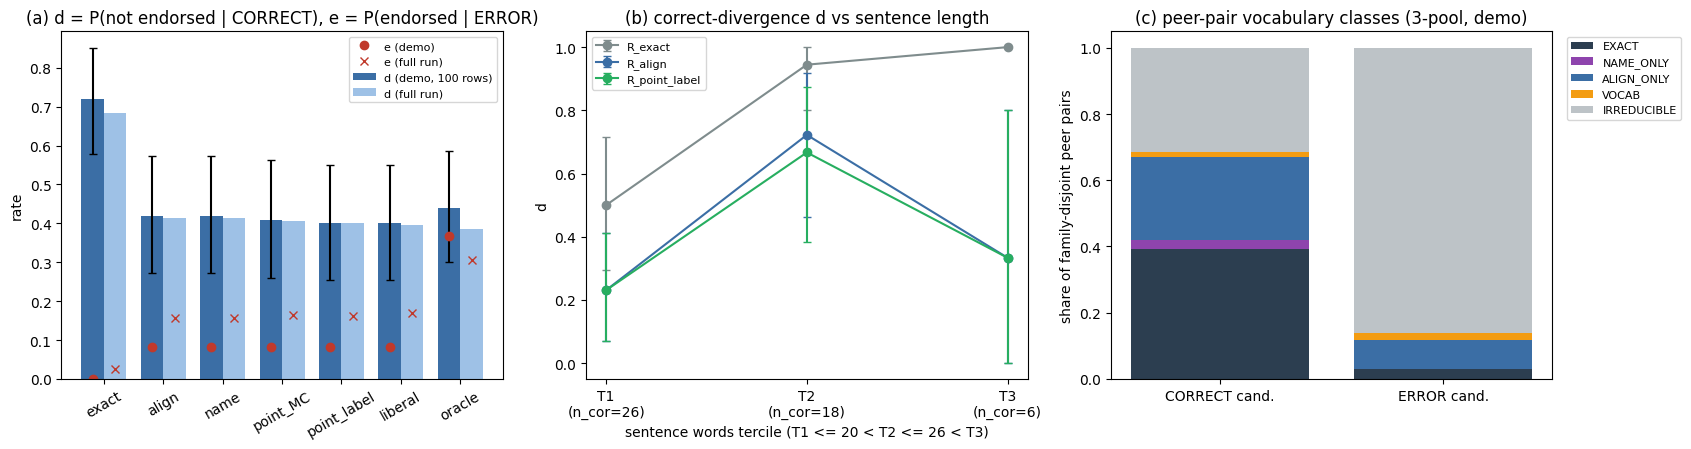


Full-run pair classes (9-family, 25,358 pairs): EXACT 13.6% | NAME_ONLY 0.3% | ALIGN_ONLY 15.1% | VOCAB 1.6% | IRREDUCIBLE 69.4%
Full-run PRIMARY: d END_MAJ 0.415 -> predicted floor 0.402 [0.336, 0.471]; gap-rule denominator 0.013 (ill-conditioned)
Full-run R_COMP: SIG d 0.260; out-of-sample calibration error -0.37 (Part-1 instruments under-count vocabulary effects)


In [15]:
pool = "3pool"
rules_plot = ["R_exact", "R_align", "R_name", "R_point_MC", "R_point_label", "R_liberal", "R_oracle"]
H = HEADS[pool]

print("PRIMARY pool (3-family), all scorable rows")
print(f"{'rule':<15}{'d demo':>9}{'95% CI':>18}{'d full':>9}   {'e demo':>8}{'e full':>9}")
for r in rules_plot:
    lo, hi = H[r]["d_ci"]
    print(f"{r:<15}{H[r]['d']:>9.3f}   [{lo:.3f}, {hi:.3f}]{FULL.get(f'p1_d_{r}_{pool}', np.nan):>9.3f}   "
          f"{H[r]['e']:>8.3f}{FULL.get(f'p1_e_{r}_{pool}', np.nan):>9.3f}")

fig, ax = plt.subplots(1, 3, figsize=(17, 4.6))
x = np.arange(len(rules_plot))
wd = 0.38
dd = np.array([H[r]["d"] for r in rules_plot])
dci = np.array([H[r]["d_ci"] for r in rules_plot], float)
ax[0].bar(x - wd / 2, dd, wd, yerr=[dd - dci[:, 0], dci[:, 1] - dd], capsize=3, label="d (demo, 100 rows)", color="#3b6ea5")
ax[0].bar(x + wd / 2, [FULL[f"p1_d_{r}_{pool}"] for r in rules_plot], wd, label="d (full run)", color="#9ec1e6")
ax[0].plot(x - wd / 2, [H[r]["e"] for r in rules_plot], "o", color="#c0392b", label="e (demo)")
ax[0].plot(x + wd / 2, [FULL[f"p1_e_{r}_{pool}"] for r in rules_plot], "x", color="#c0392b", label="e (full run)")
ax[0].set_xticks(x, [r.replace("R_", "") for r in rules_plot], rotation=30)
ax[0].set_ylabel("rate")
ax[0].set_title("(a) d = P(not endorsed | CORRECT), e = P(endorsed | ERROR)")
ax[0].legend(fontsize=8)

sub = T[(T.pool == pool) & (T.dim == "words_tercile")]
for r, c in (("R_exact", "#7f8c8d"), ("R_align", "#3b6ea5"), ("R_point_label", "#27ae60")):
    s = sub[sub.rule == r].sort_values("cell")
    lo = np.array([v[0] for v in s.d_ci], float)
    hi = np.array([v[1] for v in s.d_ci], float)
    ax[1].errorbar(s.cell, s.d, yerr=[s.d - lo, hi - s.d], marker="o", capsize=3, color=c, label=r)
cuts = data["prereg"]["words_tercile_cuts"]
nc = sub[sub.rule == "R_align"].sort_values("cell")
ax[1].set_xticks(range(len(nc)), [f"{c}\n(n_cor={n})" for c, n in zip(nc.cell, nc.n_cor)])
ax[1].set_xlabel(f"sentence words tercile (T1 <= {cuts[0]:g} < T2 <= {cuts[1]:g} < T3)")
ax[1].set_ylabel("d")
ax[1].set_title("(b) correct-divergence d vs sentence length")
ax[1].legend(fontsize=8)

sfx = "_3pool"
comp = P.groupby("y_AB")[[f"{c}{sfx}" for c in CLASSES]].sum()
comp = comp.div(comp.sum(1), axis=0)
bottom = np.zeros(len(comp))
cols = {"EXACT": "#2c3e50", "NAME_ONLY": "#8e44ad", "ALIGN_ONLY": "#3b6ea5", "VOCAB": "#f39c12", "IRREDUCIBLE": "#bdc3c7"}
for c in CLASSES:
    v = comp[f"{c}{sfx}"].values
    ax[2].bar(["CORRECT cand.", "ERROR cand."], v, bottom=bottom, label=c, color=cols[c])
    bottom += v
ax[2].set_ylabel("share of family-disjoint peer pairs")
ax[2].set_title("(c) peer-pair vocabulary classes (3-pool, demo)")
ax[2].legend(fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

print("\nFull-run pair classes (9-family, 25,358 pairs):",
      "EXACT 13.6% | NAME_ONLY 0.3% | ALIGN_ONLY 15.1% | VOCAB 1.6% | IRREDUCIBLE 69.4%")
print(f"Full-run PRIMARY: d END_MAJ {FULL['p1_d_R_align_3pool']:.3f} -> predicted floor {FULL['p1_d_floor_pred_3pool']:.3f} "
      f"[{FULL['p1_d_floor_pred_3pool_ci_lo']:.3f}, {FULL['p1_d_floor_pred_3pool_ci_hi']:.3f}]; "
      f"gap-rule denominator {FULL['p1_gap_rule_denominator_3pool']:.3f} (ill-conditioned)")
print(f"Full-run R_COMP: SIG d {FULL['p2_sig_d']:.3f}; out-of-sample calibration error {FULL['p2_validation_calib_err']:.2f} "
      "(Part-1 instruments under-count vocabulary effects)")

### Takeaways

* A shared vocabulary lowers `d` only slightly: in the full run the predicted floor is 0.402, against 0.415 under
  `END_MAJ` (3-pool). Even the liberal bound (every VOCAB pair counted) only reaches 0.396. Most disagreement with
  correct candidates is **IRREDUCIBLE**: 77% (9-family) / 61% (3-pool) of their non-agreeing peers are themselves
  labelled ERROR.
* Anchoring is not the main problem either. The no-anchoring oracle floor is 0.385 (3-pool).
* The label-free `c_vres` score adds essentially no AUROC over the align-only score.
* The Part-2 out-of-sample check (R_COMP, where peers **share a signature**) **failed**: the predicted endorsement was
  0.20 against an actual 0.575. The pair-class instruments therefore under-count what a real shared vocabulary does,
  so the estimates above are a lower bound on the vocabulary effect, not a verdict against it.